In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/IPL.csv', low_memory=False)

In [3]:
df.shape

(278205, 64)

In [4]:
print("Seasons:", sorted(df['season'].dropna().unique()))

Seasons: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025']


In [5]:
df.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [6]:
missing = df.isnull().sum()

In [7]:
missing[missing > 0]

extra_type          263072
wicket_kind         264382
player_out          264382
fielders            268192
runs_target         144302
review_batter       277333
team_reviewed       277333
review_decision     277333
umpire              277333
win_outcome           4702
superover_winner    274309
result_type         273503
method              274315
new_batter          264884
next_batter         264884
dtype: int64

C:\Users\sneha\AppData\Local\Temp\ipykernel_18876\1157609777.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_wins.values, y=team_wins.index, palette='rocket')


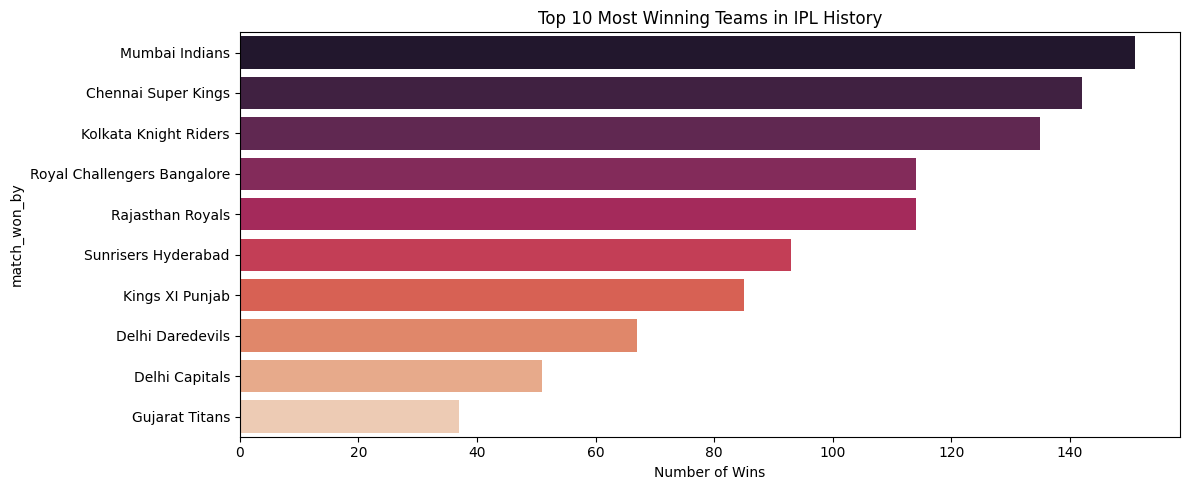

In [8]:
matches = df.drop_duplicates(subset='match_id')

plt.figure(figsize=(12, 5))
team_wins = matches['match_won_by'].value_counts().head(10)
sns.barplot(x=team_wins.values, y=team_wins.index, palette='rocket')
plt.title('Top 10 Most Winning Teams in IPL History')
plt.xlabel('Number of Wins')
plt.tight_layout()
plt.show()

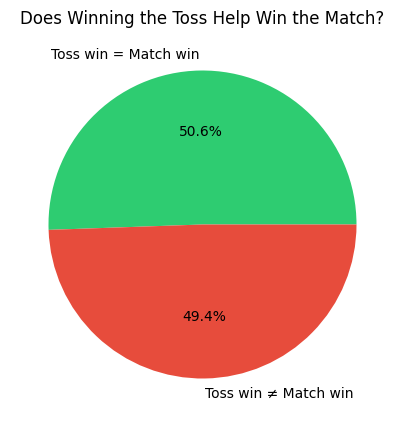

In [9]:
matches['toss_win_match_win'] = matches['toss_winner'] == matches['match_won_by']

toss_effect = matches['toss_win_match_win'].value_counts()
labels = ['Toss win = Match win', 'Toss win ≠ Match win']

plt.figure(figsize=(6, 5))
plt.pie(toss_effect.values, labels=labels, autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
plt.title('Does Winning the Toss Help Win the Match?')
plt.show()

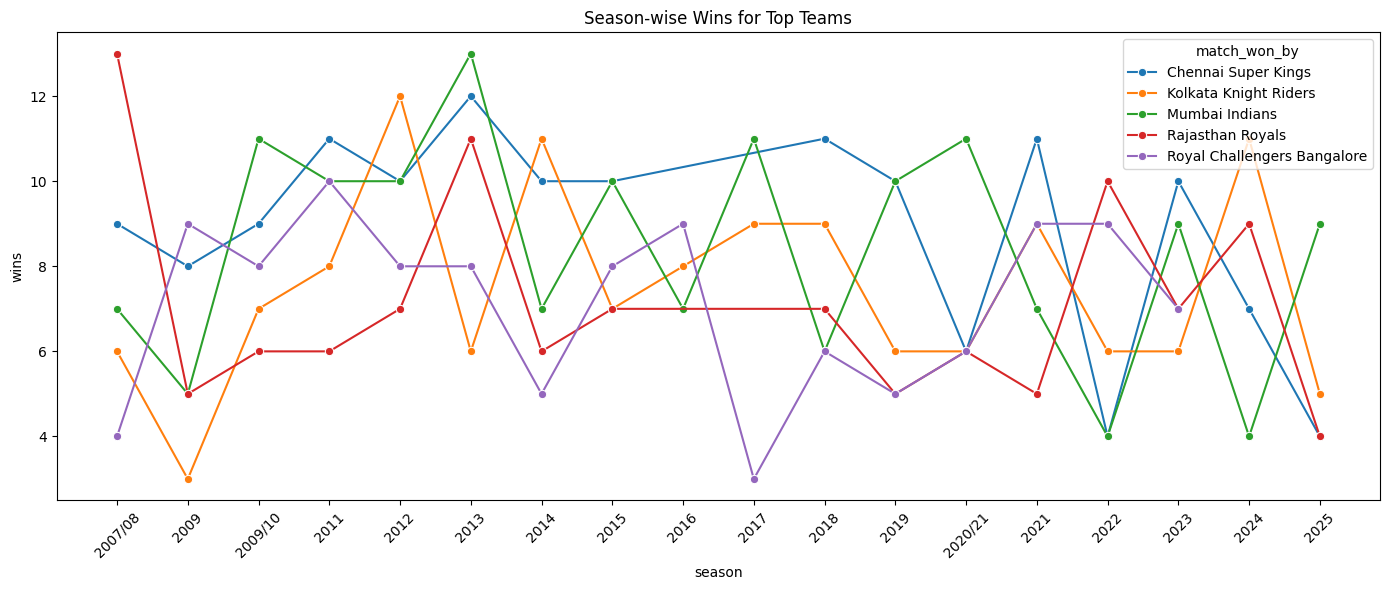

In [11]:
top_teams = ['Mumbai Indians', 'Chennai Super Kings', 
             'Kolkata Knight Riders', 'Rajasthan Royals',
             'Royal Challengers Bangalore']

season_wins = matches[matches['match_won_by'].isin(top_teams)]\
    .groupby(['season', 'match_won_by']).size().reset_index(name='wins')

plt.figure(figsize=(14, 6))
sns.lineplot(data=season_wins, x='season', y='wins', 
             hue='match_won_by', marker='o')
plt.title('Season-wise Wins for Top Teams')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

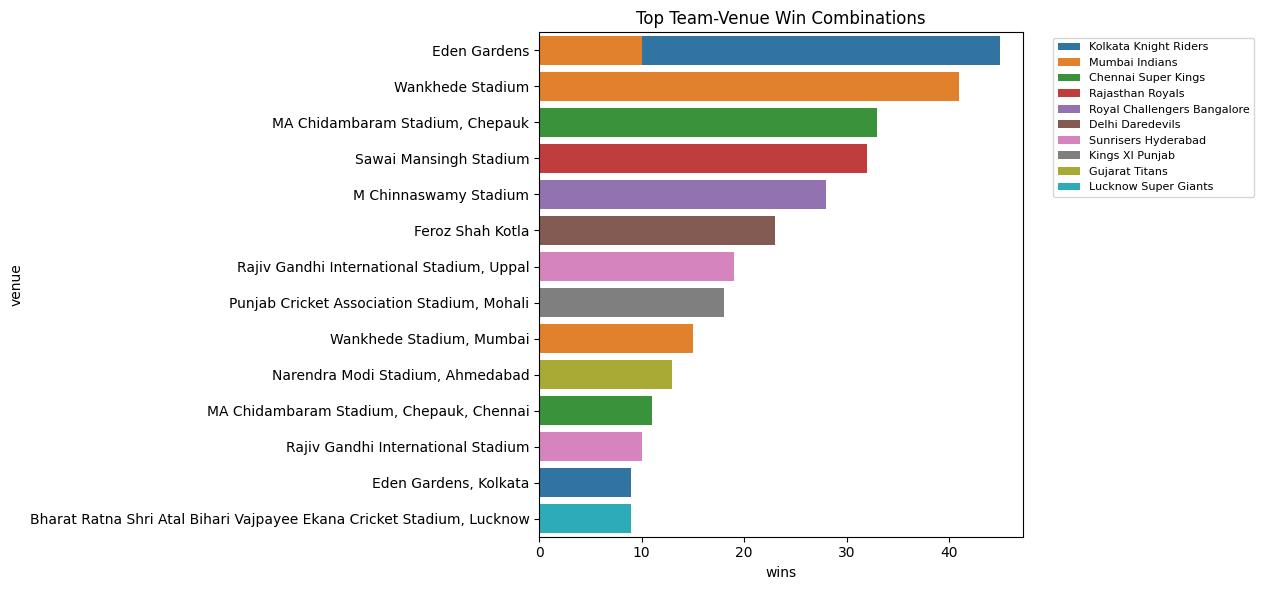

In [12]:
venue_wins = matches.groupby(['venue', 'match_won_by']).size()\
    .reset_index(name='wins').sort_values('wins', ascending=False).head(15)

plt.figure(figsize=(13, 6))
sns.barplot(data=venue_wins, x='wins', y='venue', 
            hue='match_won_by', dodge=False)
plt.title('Top Team-Venue Win Combinations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
match_df = matches.copy()
name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}
match_df['match_won_by'] = match_df['match_won_by'].replace(name_map)
match_df['toss_winner'] = match_df['toss_winner'].replace(name_map)
match_df['batting_team'] = match_df['batting_team'].replace(name_map)

print("Teams after standardization:")
print(sorted(match_df['match_won_by'].unique()))

Teams after standardization:
['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad', 'Unknown']


In [15]:
team_seasons = pd.concat([
    match_df[['season', 'batting_team']].rename(columns={'batting_team': 'team'}),
    match_df[['season', 'bowling_team']].rename(columns={'bowling_team': 'team'})
]).drop_duplicates()
wins_per_season = match_df.groupby(['season', 'match_won_by'])\
    .size().reset_index(name='wins')
wins_per_season.rename(columns={'match_won_by': 'team'}, inplace=True)
played_per_season = pd.concat([
    match_df[['season','match_id','batting_team']].rename(columns={'batting_team':'team'}),
    match_df[['season','match_id','bowling_team']].rename(columns={'bowling_team':'team'})
]).drop_duplicates().groupby(['season','team']).size().reset_index(name='played')
team_stats = played_per_season.merge(wins_per_season, on=['season','team'], how='left')
team_stats['wins'] = team_stats['wins'].fillna(0)
team_stats['win_rate'] = team_stats['wins'] / team_stats['played']

print(team_stats.sort_values(['season','win_rate'], ascending=[True, False]).head(20))

     season                         team  played  wins  win_rate
7   2007/08                 Punjab Kings       7  10.0  1.428571
2   2007/08               Delhi Capitals       6   7.0  1.166667
8   2007/08             Rajasthan Royals      16  13.0  0.812500
10  2007/08  Royal Challengers Bengaluru       7   4.0  0.571429
0   2007/08          Chennai Super Kings      16   9.0  0.562500
6   2007/08               Mumbai Indians      14   7.0  0.500000
5   2007/08        Kolkata Knight Riders      13   6.0  0.461538
11  2007/08          Sunrisers Hyderabad       8   2.0  0.250000
1   2007/08              Deccan Chargers       6   0.0  0.000000
3   2007/08             Delhi Daredevils       8   0.0  0.000000
4   2007/08              Kings XI Punjab       8   0.0  0.000000
9   2007/08  Royal Challengers Bangalore       7   0.0  0.000000
22     2009  Royal Challengers Bengaluru       6   9.0  1.500000
14     2009               Delhi Capitals       7  10.0  1.428571
19     2009              

In [16]:
toss_wins = match_df[match_df['toss_winner'] == match_df['match_won_by']]\
    .groupby('match_won_by').size().reset_index(name='toss_and_won')
toss_wins.rename(columns={'match_won_by': 'team'}, inplace=True)

total_toss = match_df.groupby('toss_winner').size().reset_index(name='total_toss')
total_toss.rename(columns={'toss_winner': 'team'}, inplace=True)

toss_stats = toss_wins.merge(total_toss, on='team')
toss_stats['toss_win_rate'] = toss_stats['toss_and_won'] / toss_stats['total_toss']

print(toss_stats.sort_values('toss_win_rate', ascending=False))

                           team  toss_and_won  total_toss  toss_win_rate
2                 Gujarat Lions            10          15       0.666667
3                Gujarat Titans            19          29       0.655172
11      Rising Pune Supergiants             8          13       0.615385
0           Chennai Super Kings            78         128       0.609375
5         Kolkata Knight Riders            71         128       0.554688
7                Mumbai Indians            82         151       0.543046
6          Lucknow Super Giants            13          24       0.541667
12  Royal Challengers Bengaluru            66         128       0.515625
4          Kochi Tuskers Kerala             4           8       0.500000
10             Rajasthan Royals            61         127       0.480315
1                Delhi Capitals            64         138       0.463768
13          Sunrisers Hyderabad            60         138       0.434783
9                  Punjab Kings            52      

In [18]:
recent_seasons = ['2022', '2023', '2024', '2025']
recent_stats = team_stats[team_stats['season'].isin(recent_seasons)]

avg_win_rate = recent_stats.groupby('team')['win_rate'].mean()\
    .reset_index(name='avg_win_rate')

model_features = avg_win_rate.merge(toss_stats[['team','toss_win_rate']], 
                                     on='team', how='left')

ipl_2026 = pd.DataFrame({
    'team': ['Rajasthan Royals', 'Delhi Capitals', 'Punjab Kings',
             'Royal Challengers Bengaluru', 'Sunrisers Hyderabad',
             'Mumbai Indians', 'Gujarat Titans', 'Lucknow Super Giants',
             'Kolkata Knight Riders', 'Chennai Super Kings'],
    'current_pts': [4, 4, 4, 2, 2, 2, 0, 0, 0, 0],
    'current_nrr': [2.233, 1.170, 0.637, 2.907, 0.469, -0.206, 
                    -0.424, -1.397, -1.964, -2.0]
})

model_features = model_features.merge(ipl_2026, on='team', how='right')
model_features = model_features.fillna(0)

print(model_features)

                          team  avg_win_rate  toss_win_rate  current_pts  \
0             Rajasthan Royals      0.493487       0.480315            4   
1               Delhi Capitals      0.439286       0.463768            4   
2                 Punjab Kings      0.460317       0.426230            4   
3  Royal Challengers Bengaluru      0.744444       0.515625            2   
4          Sunrisers Hyderabad      0.426339       0.434783            2   
5               Mumbai Indians      0.424107       0.543046            2   
6               Gujarat Titans      0.603431       0.655172            0   
7         Lucknow Super Giants      0.515476       0.541667            0   
8        Kolkata Knight Riders      0.506868       0.554688            0   
9          Chennai Super Kings      0.424107       0.609375            0   

   current_nrr  
0        2.233  
1        1.170  
2        0.637  
3        2.907  
4        0.469  
5       -0.206  
6       -0.424  
7       -1.397  
8       -1

In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features = ['avg_win_rate', 'toss_win_rate', 'current_pts', 'current_nrr']

model_features[features] = scaler.fit_transform(model_features[features])

model_features['prediction_score'] = (
    model_features['avg_win_rate']   * 0.40 +
    model_features['current_pts']    * 0.35 +
    model_features['toss_win_rate']  * 0.15 +
    model_features['current_nrr']    * 0.10
)

result = model_features[['team', 'prediction_score']]\
    .sort_values('prediction_score', ascending=False).reset_index(drop=True)
result.index += 1
result.columns = ['Team', 'Score']
result['Score'] = result['Score'].round(4)

print("🏆 IPL 2026 WINNER PREDICTION")
print("="*40)
print(result.to_string())

🏆 IPL 2026 WINNER PREDICTION
                           Team   Score
1   Royal Challengers Bengaluru  0.7336
2              Rajasthan Royals  0.5583
3                Delhi Capitals  0.4581
4                  Punjab Kings  0.4490
5                Gujarat Titans  0.4060
6                Mumbai Indians  0.2881
7           Sunrisers Hyderabad  0.2337
8          Lucknow Super Giants  0.2020
9         Kolkata Knight Riders  0.1882
10          Chennai Super Kings  0.1200


C:\Users\sneha\AppData\Local\Temp\ipykernel_18876\4257267115.py:15: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sneha\OneDrive\Desktop\JBooks\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


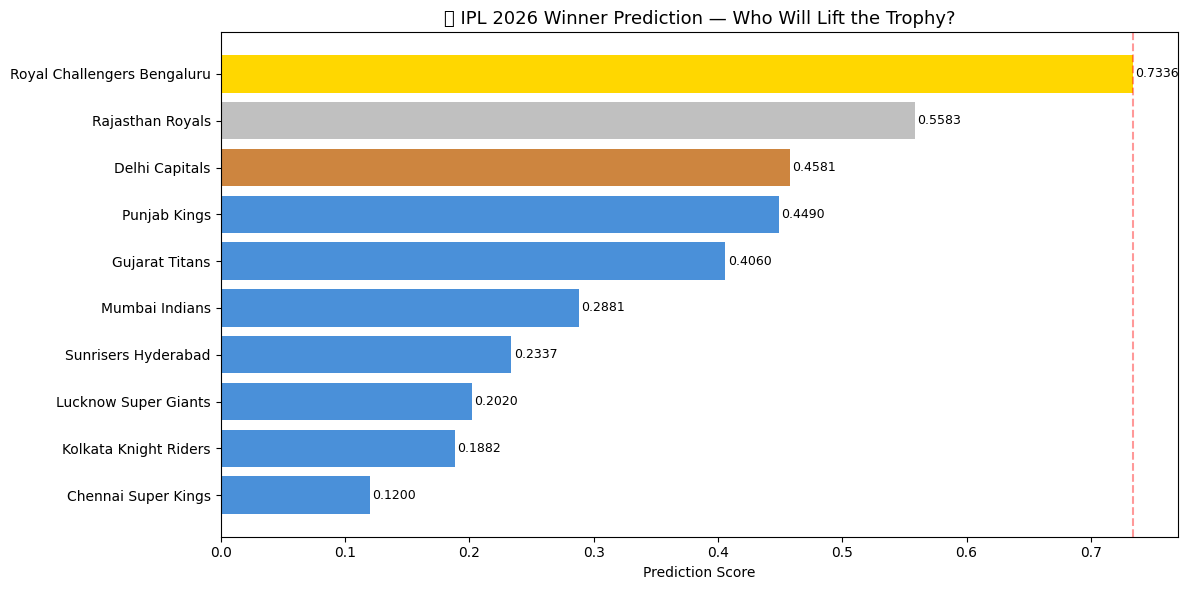


🥇 PREDICTED WINNER: Royal Challengers Bengaluru
🥈 Runner Up:        Rajasthan Royals
🥉 3rd Place:        Delhi Capitals


In [22]:
plt.figure(figsize=(12, 6))
colors = ['gold' if i == 0 else 'silver' if i == 1 else 
          'peru' if i == 2 else '#4a90d9' 
          for i in range(len(result))]

bars = plt.barh(result['Team'][::-1], result['Score'][::-1], color=colors[::-1])
plt.xlabel('Prediction Score')
plt.title('🏆 IPL 2026 Winner Prediction — Who Will Lift the Trophy?', fontsize=13)
plt.axvline(x=result['Score'].max(), color='red', linestyle='--', alpha=0.4)

for bar, score in zip(bars, result['Score'][::-1]):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n🥇 PREDICTED WINNER: {result.iloc[0]['Team']}")
print(f"🥈 Runner Up:        {result.iloc[1]['Team']}")
print(f"🥉 3rd Place:        {result.iloc[2]['Team']}")

In [24]:
result.to_csv('../data/ipl_2026_predictions.csv', index=False)
model_features.to_csv('../data/model_features.csv', index=False)